# BrainPy-style point-neuron modeling with ``brainpy.state``

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chaobrain/brainx/blob/main/docs/tutorials/brainpy_point_neuron_networks.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/chaobrain/brainx/blob/main/docs/tutorials/brainpy_point_neuron_networks.ipynb)

## What is `brainpy.state`?
``brainpy.state`` is the point-neuron modeling package in the BrainX ecosystem. It is used to build spiking neural systems from stateful neurons, synapses, projections, inputs, and readouts. The package keeps neural dynamics explicit, works with physical units through ``brainunit``, and runs on top of JAX-compatible state transformations from ``brainstate``. 

For point-neuron networks, ``brainpy.state`` provides two complementary modeling routes:

- [**BrainPy-style models**](https://brainx.chaobrain.com/brainpy-state/brainpy-style/index.html) use the native BrainX style. You compose neurons, synapses, projections, and output models directly, which makes the code close to the model anatomy and convenient for scalable, differentiable workflows.
- [**NEST-compatible models**](https://brainx.chaobrain.com/brainpy-state/nest-style/index.html) keep a familiar NEST-style workflow for users who want to create nodes, connect populations and devices, simulate a time window, and record traces or spikes. 

For the full API reference, model catalogs, and additional examples across both routes, read the complete [brainpy.state documentation](https://brainx.chaobrain.com/brainpy-state/).

This tutorial focuses on the **BrainPy-style modeling** : assembling networks from explicit, stateful parts and running them with unit-aware dynamics. The examples progress from a single ``LIFRef`` population to connected recurrent circuits, showing how neuron state, synaptic dynamics, connectivity, and output models work together. 

You will learn how to:

- create and inspect a refractory leaky integrate-and-fire population with ``brainpy.state.LIFRef``;
- drive stateful neurons through time with ``brainstate.transform.for_loop``;
- read the four parts of a projection: ``comm``, ``syn``, ``out``, and ``post``;
- understand why ``AlignPostProj`` is useful for convergent recurrent networks;
- build and visualize a compact conductance-based excitatory/inhibitory network.


## 1. Setup and mental model

Most BrainPy-style models are unit-aware. Set the global simulation time step before creating and running the model. The examples below use small populations so the states, shapes, and plots are easy to inspect.

In [9]:
import numpy as np
import matplotlib.pyplot as plt

import brainunit as u
import brainstate
import braintools
import brainpy.state

brainstate.environ.set(dt=0.1 * u.ms)
brainstate.random.seed(0)

dt = brainstate.environ.get_dt()
print("dt =", dt)

dt = 0.1 ms


## 2. A first ``LIFRef`` population

``brainpy.state.LIFRef`` is a refractory leaky integrate-and-fire neuron population. The population owns its dynamical variables as state: membrane potential ``V`` and refractory timing are stored inside the module, while calling the module once advances the dynamics by one time step.

The constructor uses physical units from ``brainunit``. A threshold is in millivolts, a time constant is in milliseconds, and injected current is in milliamps. This makes the equations readable and catches many unit mistakes early.

In [10]:
num_neurons = 16

lif = brainpy.state.LIFRef(
    num_neurons,
    V_rest=-60.0 * u.mV,
    V_th=-50.0 * u.mV,
    V_reset=-60.0 * u.mV,
    tau=20.0 * u.ms,
    tau_ref=5.0 * u.ms,
    V_initializer=braintools.init.Normal(-60.0 * u.mV, 3.0 * u.mV),
)

brainstate.nn.init_all_states(lif)
lif

LIFRef(
  in_size=(16,),
  out_size=(16,),
  spk_reset=soft,
  spk_fun=ReluGrad(alpha=0.3, width=1.0),
  R=Quantity(1., "ohm"),
  tau=Quantity(20., "ms"),
  tau_ref=Quantity(5., "ms"),
  V_th=Quantity(-50., "mV"),
  V_rest=Quantity(-60., "mV"),
  V_reset=Quantity(-60., "mV"),
  V_initializer=Normal(mean=-60. mV, std=3. mV),
  V=HiddenState(
    value=Quantity(float32[16], "mV")
  ),
  last_spike_time=ShortTermState(
    value=Quantity(~float32[16], "ms")
  )
)

## 3. Drive the population with ``for_loop``

A model update is written as a normal Python function for one time step. ``brainstate.transform.for_loop`` lowers that step function over a time axis, carries the model state from one step to the next, and stacks the returned values.

The per-step function sets the current simulation time with ``brainstate.environ.context(t=t)``. This is the standard pattern for time-dependent neural dynamics in ``brainpy.state``.

In [11]:
def run_lif_population(currents):
    lif.reset_state()
    times = u.math.arange(0.0 * u.ms, len(currents) * dt, dt)

    def step(t, current):
        with brainstate.environ.context(t=t):
            spike = lif(current)
            return lif.V.value, spike

    voltages, spikes = brainstate.transform.for_loop(step, times, currents)
    return times, voltages, spikes

n_steps = 600
constant_current = 25.0 * u.mA
currents = np.ones(n_steps) * constant_current

times, voltages, spikes = run_lif_population(currents)

print("voltages:", voltages.shape)
print("spikes:", spikes.shape)
print("total spikes:", float(u.math.sum(spikes)))

voltages: (600, 16)
spikes: (600, 16)
total spikes: 64.0


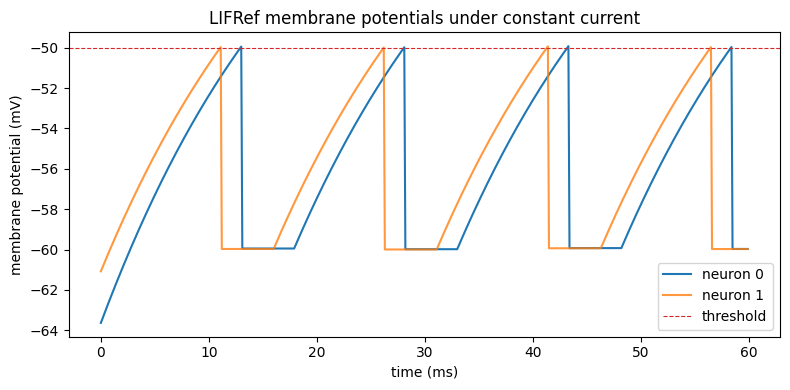

In [12]:
time_ms = times.to_decimal(u.ms)
voltage_mV = voltages.to_decimal(u.mV)

plt.figure(figsize=(8, 4))
plt.plot(time_ms, voltage_mV[:, 0], label="neuron 0")
plt.plot(time_ms, voltage_mV[:, 1], label="neuron 1", alpha=0.8)
plt.axhline(-50.0, color="tab:red", ls="--", lw=0.8, label="threshold")
plt.xlabel("time (ms)")
plt.ylabel("membrane potential (mV)")
plt.title("LIFRef membrane potentials under constant current")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 4. Projection anatomy: ``comm``, ``syn``, ``out``, ``post``

A projection connects a presynaptic event stream to a postsynaptic target. In BrainPy-style modeling, a projection is built from four explicit roles:

- ``comm``: communication or connectivity, such as ``brainstate.nn.EventFixedProb``;
- ``syn``: synaptic dynamics, such as ``brainpy.state.Expon``;
- ``out``: output conversion, such as ``brainpy.state.COBA`` for conductance-based output or ``brainpy.state.CUBA`` for current-based output;
- ``post``: the postsynaptic population that receives the current.

This decomposition lets you swap connectivity, synapse kinetics, and output biophysics independently. It also makes the central memory question explicit: where should synaptic state live?

A naive simulator can store one dynamical variable per realized synapse. For sparse recurrent networks, that means memory grows with the number of connected pairs. ``brainpy.state`` avoids this by aligning synaptic state to a neuron dimension instead of a connection dimension. The temporal state is stored either on the presynaptic side or on the postsynaptic side, while the projection still computes the same drive.

![AlignPre and AlignPost projection design](https://brainx.chaobrain.com/brainpy-state/_images/alignpre-alignpost.png)

Figure: **AlignPre vs AlignPost.** The synapse-dynamics block sits before the connection matrix on the left (state aligned to the presynaptic population, memory ``O(N_pre)``, natural for one-to-many communication) and after the connection matrix on the right (state aligned to the postsynaptic population, memory ``O(N_post)``, natural for many-to-one fan-in with exponential-family synapses). Orange indicates presynaptic activity, blue indicates postsynaptic activity, and green indicates communication through the connectivity matrix.

**``AlignPre`` aligns synaptic state with the presynaptic population.** Each presynaptic neuron maintains its own trace before communication distributes it to targets. This is useful when one source is reused across many targets, or when the synapse model is naturally updated before communication.

**``AlignPost`` aligns synaptic state with the postsynaptic population.** Presynaptic events are first communicated and accumulated for each target. The synapse dynamics then evolve on the postsynaptic side. For exponential-family synapses, incoming events can be merged before the state update, so the result is exact while memory scales with the target population size.

The E/I network below uses ``AlignPostProj`` because excitatory and inhibitory presynaptic slices both converge back onto the same LIFRef population.

## 5. Build a compact conductance-based E/I network

The network below extends the same BrainPy-style pattern to a compact recurrent circuit: one mixed ``LIFRef`` population, one excitatory recurrent projection, and one inhibitory recurrent projection.

The projections are conductance-based. Excitatory input uses ``COBA(E=0 mV)`` and inhibitory input uses ``COBA(E=-80 mV)``. Each projection has its own exponential synapse time constant and connectivity pattern.

In [13]:
class EINet(brainstate.nn.Module):
    """A compact conductance-based recurrent E/I network."""

    def __init__(self, n_exc, n_inh, prob, exc_weight, inh_weight):
        super().__init__()
        self.n_exc = n_exc
        self.n_inh = n_inh
        self.num = n_exc + n_inh

        self.neurons = brainpy.state.LIFRef(
            self.num,
            V_rest=-60.0 * u.mV,
            V_th=-50.0 * u.mV,
            V_reset=-60.0 * u.mV,
            tau=20.0 * u.ms,
            tau_ref=5.0 * u.ms,
            V_initializer=braintools.init.Normal(-55.0 * u.mV, 2.0 * u.mV),
        )

        self.exc = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(n_exc, self.num, prob, exc_weight),
            syn=brainpy.state.Expon.desc(self.num, tau=5.0 * u.ms),
            out=brainpy.state.COBA.desc(E=0.0 * u.mV),
            post=self.neurons,
        )
        self.inh = brainpy.state.AlignPostProj(
            comm=brainstate.nn.EventFixedProb(n_inh, self.num, prob, inh_weight),
            syn=brainpy.state.Expon.desc(self.num, tau=10.0 * u.ms),
            out=brainpy.state.COBA.desc(E=-80.0 * u.mV),
            post=self.neurons,
        )

    def update(self, t, background_current):
        with brainstate.environ.context(t=t):
            previous_spikes = self.neurons.get_spike() != 0.0
            self.exc(previous_spikes[:self.n_exc])
            self.inh(previous_spikes[self.n_exc:])
            self.neurons(background_current)
            return self.neurons.get_spike()

## 6. Initialize and inspect the network

State allocation is explicit. ``brainstate.nn.init_all_states`` walks the module tree and creates the dynamical state variables for the neuron population and synapses. The connection weights are conductances, so both excitatory and inhibitory projection weights are positive; the sign of their effect comes from the reversal potential in ``COBA``.

In [14]:
n_exc = 320
n_inh = 80
prob = 0.02

exc_weight = 0.6 * u.mS
inh_weight = 6.7 * u.mS
background_current = 20.0 * u.mA

net = EINet(n_exc, n_inh, prob, exc_weight, inh_weight)
brainstate.nn.init_all_states(net)
net

EINet(
  n_exc=320,
  n_inh=80,
  num=400,
  neurons=LIFRef(
    in_size=(400,),
    out_size=(400,),
    before_updates={
      "(<class 'brainpy.state.Expon'>, (400,), {'tau': '5. ms'}) // (<class 'brainpy.state.COBA'>, (), {'E': '0. mV'})": _AlignPost(
        syn=Expon(
          in_size=(400,),
          out_size=(400,),
          tau=Quantity(5., "ms"),
          g_initializer=Constant(value=0. mS),
          g=HiddenState(
            value=Quantity(~float32[400], "mS")
          )
        ),
        out=COBA(
          E=Quantity(0., "mV")
        )
      ),
      "(<class 'brainpy.state.Expon'>, (400,), {'tau': '10. ms'}) // (<class 'brainpy.state.COBA'>, (), {'E': '-80. mV'})": _AlignPost(
        syn=Expon(
          in_size=(400,),
          out_size=(400,),
          tau=Quantity(10., "ms"),
          g_initializer=Constant(value=0. mS),
          g=HiddenState(
            value=Quantity(~float32[400], "mS")
          )
        ),
        out=COBA(
          E=Quantity(-8

## 7. Run and visualize the recurrent simulation

Each time step uses spikes from the previous step to update recurrent synaptic input, then advances the neuron population. ``for_loop`` returns a time-by-neuron spike matrix that can be plotted as a raster.

In [15]:
duration = 300.0 * u.ms
times = u.math.arange(0.0 * u.ms, duration, brainstate.environ.get_dt())

spike_history = brainstate.transform.for_loop(
    lambda t: net.update(t, background_current),
    times,
    pbar=brainstate.transform.ProgressBar(20),
)

print("spike_history:", spike_history.shape)
print("total spikes:", float(u.math.sum(spike_history)))

  0%|          | 0/3000 [00:00<?, ?it/s]

spike_history: (3000, 400)
total spikes: 6400.0


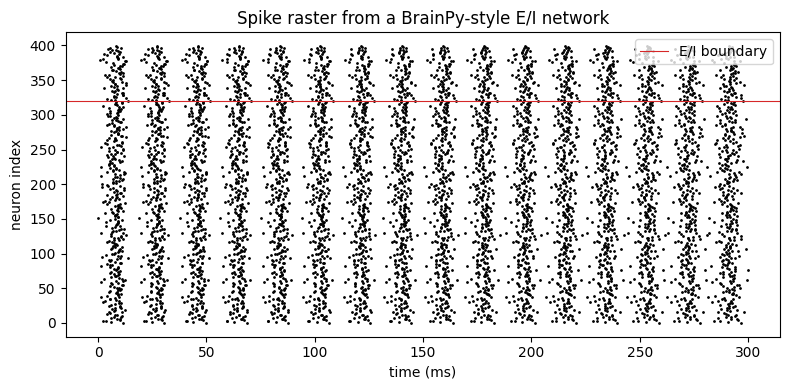

In [16]:
t_indices, neuron_indices = u.math.where(spike_history)
time_ms = times.to_decimal(u.ms)

plt.figure(figsize=(8, 4))
plt.scatter(time_ms[t_indices], neuron_indices, s=1, color="black")
plt.axhline(n_exc - 0.5, color="tab:red", lw=0.8, label="E/I boundary")
plt.xlabel("time (ms)")
plt.ylabel("neuron index")
plt.title("Spike raster from a BrainPy-style E/I network")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

## Troubleshooting

- **No spikes:** increase ``background_current`` or simulate for a longer duration.
- **Runaway activity:** reduce ``exc_weight``, strengthen inhibition, or shorten the excitatory synaptic time constant.
- **Shape errors:** make sure ``EventFixedProb(n_pre, n_post, ...)`` matches the presynaptic slice and postsynaptic population. In this tutorial, the synaptic state uses ``self.num`` because ``AlignPostProj`` aligns it to the target population.
- **Unit errors:** keep time constants in ``u.ms``, voltages in ``u.mV``, currents in ``u.mA``, and conductance weights in ``u.mS``.
- **Repeated independent runs:** call ``brainstate.nn.init_all_states(model)`` before a new run, or call the relevant ``reset_state`` method when you want to reuse the same module.

## Summary

This tutorial introduced the essential BrainPy-style workflow for point-neuron modeling with ``brainpy.state``. You created a refractory LIF population, advanced stateful neural dynamics with ``brainstate.transform.for_loop``, examined how projections are organized into ``comm``, ``syn``, ``out``, and ``post`` components, and built a compact conductance-based excitatory/inhibitory recurrent network.

These examples are meant to provide a concise starting point. For more detailed content, see the complete [``brainpy.state`` documentation](https://brainx.chaobrain.com/brainpy-state/).
